In [2]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.9 MB/s eta 0:00:0000:010:01


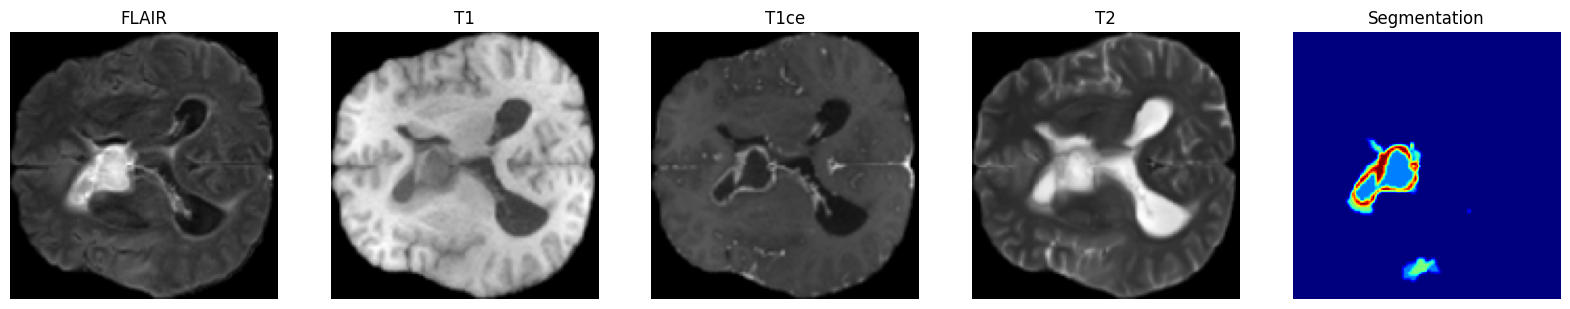

In [11]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, Spacingd, ScaleIntensityRanged,
    CropForegroundd, Resized, ToTensord, Compose
)
from monai.data import Dataset, DataLoader

# 🟢 مسار البيانات
data_dir = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"
patients = sorted(os.listdir(data_dir))

data_dicts = []
for patient in patients:
    patient_path = os.path.join(data_dir, patient)
    
    # 🟢 البحث عن الملفات داخل مجلد المريض
    modalities = ["flair", "t1", "t1ce", "t2"]
    files = {}

    # ✅ التحقق من وجود كل موداليتي قبل إضافته
    for mod in modalities:
        file_path = glob.glob(os.path.join(patient_path, f"*_{mod}.nii"))
        if file_path:
            files[mod] = file_path[0]
    
    # ✅ التحقق من وجود ملف التسمية (Segmentation)
    seg_file = glob.glob(os.path.join(patient_path, "*_seg.nii"))
    if seg_file:
        files["seg"] = seg_file[0]

    # ✅ فقط أضف المريض إذا كان يملك كل الصور المطلوبة
    if len(files) == 5:  
        data_dicts.append(files)

# ✅ تعريف التحويلات (Preprocessing)
transforms = Compose([
    LoadImaged(keys=["flair", "t1", "t1ce", "t2", "seg"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t1ce", "t2", "seg"]),
    Spacingd(
        keys=["flair", "t1", "t1ce", "t2", "seg"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "bilinear", "nearest"),
    ),
    ScaleIntensityRanged(keys=["flair", "t1", "t1ce", "t2"], a_min=0, a_max=4000, b_min=0, b_max=1, clip=True),
    CropForegroundd(keys=["flair", "t1", "t1ce", "t2", "seg"], source_key="flair"),
    Resized(keys=["flair", "t1", "t1ce", "t2", "seg"], spatial_size=(128, 128, 128)),  # ✅ توحيد الحجم
    ToTensord(keys=["flair", "t1", "t1ce", "t2", "seg"])
])

# ✅ تحميل البيانات إلى PyTorch DataLoader
dataset = Dataset(data=data_dicts, transform=transforms)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# ✅ تحميل عينة واحدة
batch = next(iter(dataloader))

# ✅ اختيار شريحة وسطية من الصورة ثلاثية الأبعاد
mid_slice = 64  # نصف 128

# 🖼️ رسم الصور بعد المعالجة المسبقة
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

modalities = ["flair", "t1", "t1ce", "t2", "seg"]
titles = ["FLAIR", "T1", "T1ce", "T2", "Segmentation"]

for i, mod in enumerate(modalities):
    img = batch[mod].squeeze().numpy()  # تحويل التينسور إلى numpy
    img_slice = img[:, :, mid_slice]  # اختيار شريحة وسطية
    
    # ✅ إذا كان القناع، استخدم خريطة ألوان مختلفة
    cmap = "gray" if mod != "seg" else "jet"
    
    axes[i].imshow(img_slice, cmap=cmap)
    axes[i].set_title(titles[i])
    axes[i].axis("off")

plt.show()
